# 10 — Calculate commodity delta

Calculate commodity price sensitivity by commodity, bucket and tenor.

Brent, WTI and gold remain distinct exact factors even when two products share a regulatory bucket.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

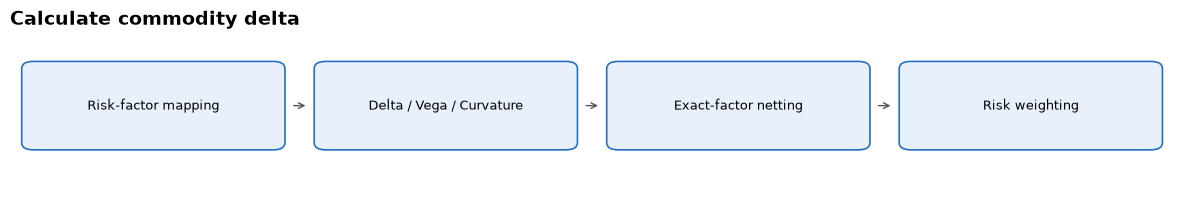

In [2]:
draw_flow(['Risk-factor mapping', 'Delta / Vega / Curvature', 'Exact-factor netting', 'Risk weighting'],'Calculate commodity delta',wrap_after=4)

Apply a 1% relative commodity-price bump, reprice, and divide by 0.01.

$$s_k=\frac{V(C_k\times1.01)-V(C_k)}{0.01}$$

In [3]:
from frtb_engine.parameters import risk_weight
delta=pd.read_csv(RUN/'03_delta_trade_level.csv')
view=delta[delta.risk_class=='COMMODITY'].copy()
view['value_change_for_bump_inr']=view.shocked_value_inr-view.base_value_inr
view['bump_unit']=np.where(view.relative,'1% relative move','1 basis point')
view['applicable_risk_weight']=view.apply(lambda row:risk_weight(row.to_dict(),'DELTA'),axis=1)
view['tenor_display']=view.apply(
    lambda row:f"{row.tenor:g} years" if pd.notna(row.tenor)
    else 'Not applicable for this risk factor',axis=1)
columns=['trade_id','instrument_type','currency','risk_class','bucket','risk_factor_id','tenor_display',
         'bump_unit','applicable_risk_weight','base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity']
shown=crore_table(view[columns],['base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity'])
display_sample(percent_columns(shown,['applicable_risk_weight']),25)
print('The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.')
example=view.iloc[0]
print(f"Worked trade: {example.trade_id} | factor: {example.risk_factor_id}")
print(f"Base value: INR {example.base_value_inr/INR_CRORE:,.4f} crore")
print(f"Shocked value: INR {example.shocked_value_inr/INR_CRORE:,.4f} crore")
print(f"Value change for bump: INR {example.value_change_for_bump_inr:,.2f}")
print(f"Sensitivity = value change / bump = INR {example.raw_sensitivity:,.2f} per unit change")

Displayed rows: first 7 of 7 observations, in table order.


,trade_id,instrument_type,currency,risk_class,bucket,risk_factor_id,tenor_display,bump_unit,Applicable Risk Weight (%),Base Value (INR crore),Shocked Value (INR crore),Value Change For Bump (INR crore),Raw Sensitivity (INR crore per unit change)
90,M01,COMMODITY_FUTURE,USD,COMMODITY,2,BRENT_0.25Y_GLOBAL,0.25 years,1% relative move,35.0000,0.8620,1.5861,0.7241,72.4080
92,M02,COMMODITY_FUTURE,USD,COMMODITY,2,BRENT_1.0Y_GLOBAL,1 years,1% relative move,35.0000,0.6896,0.1103,-0.5793,-57.9264
94,M03,COMMODITY_FUTURE,USD,COMMODITY,2,WTI_0.5Y_GLOBAL,0.5 years,1% relative move,35.0000,0.6034,1.0861,0.4827,48.2720
96,M04,COMMODITY_FUTURE,USD,COMMODITY,7,GOLD_0.25Y_GLOBAL,0.25 years,1% relative move,20.0000,0.3448,0.7551,0.4103,41.0312
98,M05,COMMODITY_FUTURE,USD,COMMODITY,7,GOLD_1.0Y_GLOBAL,1 years,1% relative move,20.0000,0.2586,-0.0491,-0.3077,-30.7734
101,M06,COMMODITY_OPTION,USD,COMMODITY,2,BRENT_0.5Y_GLOBAL,0.5 years,1% relative move,35.0000,4.0550,4.2836,0.2286,22.8589
104,M07,COMMODITY_OPTION,USD,COMMODITY,7,GOLD_1.0Y_GLOBAL,1 years,1% relative move,20.0000,-0.7613,-0.7060,0.0553,5.5264


The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.
Worked trade: M01 | factor: BRENT_0.25Y_GLOBAL
Base value: INR 0.8620 crore
Shocked value: INR 1.5861 crore
Value change for bump: INR 7,240,800.00
Sensitivity = value change / bump = INR 724,080,000.00 per unit change


The visual below uses the calculated rows shown above.

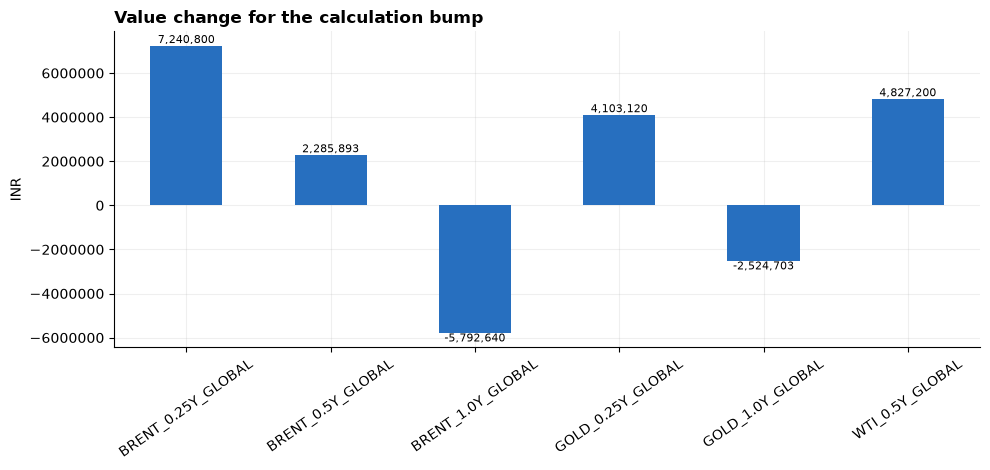

In [4]:
bar_inr(view.groupby('risk_factor_id')['value_change_for_bump_inr'].sum(),'Value change for the calculation bump')

Commodity identity and tenor remain visible before correlation aggregation.